# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código


In [5]:
plans.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
users.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
usage.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
# cantidad de nulos para usage
print(usage.isna().sum())# Cantidad de valores nulos)
print(usage.isna().mean())# Proporción de valores nulos)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


En el dataset USERS: 

Columna CITY presenta un porcentaje de nulos del 11.7%: Mi diagnostico es que esta proporcion aunque es moderada puede alterar el analisis grafico, por ende se debe imputar si la ciudad es relevante o dejar nulos si definitivamente no influye en el modelo.

Columna churn_date presenta un porcentaje de nulos del 88.3%: Mi diagnostico es que es un valor exorbitante que refleja usuarios que no han cancelado. Por ende, la recomendacion seria mantener (no imputar). Es normal ya que nulo=usuarios activos.

En el dataset USAGE:

Columna DATE presenta un porcentaje del 0.12% el cual es muy bajo y podria reflejar errores en el registro. Yo imputaria con fechas mas cercanas o eliminaria las filas considerando que su impacto seria minimo.

Columna DURATION presenta un 55.1% lo cual es mas de la mitad que esta vacio, es una variable que carece de informacion y requiere ser investigada a fondo para saber si depende del tipo de uso. Si no se puede recuperar yo eliminaria la columna.

Finalmente, la columna LENGTH presenta un porcentaje de 44.7% de nulos, similar a la anterior es un elevado porcentaje que requiere investigacion relacionandola con TYPE, si no es recuperable la eliminaria. 

En resumen, en users, los nulos son esperables:

city tiene un nivel moderado de nulos → imputación opcional.
churn_date debe permanecer nulo para usuarios activos → no imputar.

En usage, los nulos son más problemáticos:

date tiene pocos nulos → imputación simple o eliminación de filas.

duration y length tienen demasiados nulos → investigar su origen; si no hay forma de reconstruirlos, lo mejor es eliminar estas columnas para evitar sesgos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
print(users['user_id'].describe())
print(users['age'].describe()) # explorar columnas numéricas de users

count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64



Columna user_id

- Tiene 4000 registros, sin valores nulos.
- El rango va de 10 000 a 13 999, lo que confirma que es un identificador consecutivo y único.
- No aporta información analítica, pero es útil para unir tablas o verificar duplicados.
Mi Conclusión: Columna limpia, sin anomalías.

Columna age

- También tiene 4000 registros, pero el valor mínimo es –999, lo cual es un sentinel claro (valor inválido usado para representar datos faltantes).

- La media (≈33.7) y el máximo (79) son razonables, pero el desvío estándar (≈123) es excesivo, causado por ese valor negativo extremo.
Mi Conclusión: Se debe reemplazar –999 por NaN para evitar distorsión en estadísticas y análisis posteriores.

In [15]:
print(usage['id'].describe())
print(usage['user_id'].describe())
print(usage['duration'].describe())
print(usage['length'].describe())

count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64
count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64


Columna id

- Tiene 40 000 registros, con valores consecutivos del 1 al 40 000.
- Es un identificador único, sin nulos ni valores repetidos.
Mi Conclusión: Columna limpia, sin relevancia analítica directa.

Columna user_id

- También tiene 40 000 registros, con rango entre 10 000 y 13 999.
- Coincide con los identificadores del dataset users, lo que confirma una relación correcta entre ambas tablas.
Mi Conclusión: Columna íntegra y útil para realizar uniones (merge) entre datasets.

Columna duration

- Solo cuenta con 17 924 registros válidos, lo que implica más del 55 % de nulos.
- Los valores van de 0 a 120, con una media de 5.2 y desviación estándar de 6.8.
- El valor mínimo 0 podría representar sentinels o registros sin actividad.
Mi  Conclusión: Revisar si los nulos y ceros corresponden a tipos de uso específicos (text o call). Si no aportan información, eliminar o imputar según contexto.

Columna length

- Tiene 22 104 registros válidos, lo que indica 44 % de nulos.
- Rango de 0 a 1490, con media de 52.1 y desviación estándar de 56.6.
- Los valores extremos (1490) podrían ser outliers o errores de captura.
Mi Conclusión: Investigar la relación entre length y duration. Si los valores altos son inconsistentes, aplicar limpieza o recorte de outliers.

In [16]:
# explorar columnas categóricas de users
columnas_users = ['city', 'plan']
print(users['city'].value_counts(dropna=False))
print(users['plan'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


La columna city

- Contiene 8 categorías principales: Bogotá, CDMX, Medellín, GDL, Cali, MTY, además de valores faltantes (NaN) y un marcador '?'.

- Los valores 'NaN' (469) y '?' (96) representan sentinels o datos faltantes, equivalentes a usuarios sin ciudad registrada o con errores de carga.

- Las ciudades más frecuentes son Bogotá (808) y CDMX (730), lo que sugiere una concentración de usuarios en estas zonas.

Mi Conclusión: La variable es útil para análisis geográfico, pero requiere limpieza: reemplazar '?' por NaN y decidir si imputar o excluir los nulos.

La columna plan

- Presenta dos categorías: 'Basico' (2595) y 'Premium' (1405).
- No hay valores nulos ni sentinels.
- La distribución muestra que el plan Básico tiene mayor participación (≈65%), lo que indica una base de usuarios más amplia en el nivel inicial.

Mi Conclusión: Variable limpia y directamente utilizable para segmentación o análisis de comportamiento.

In [17]:
# explorar columna categórica de usage
print(usage['type'].value_counts(dropna=False)) # completa el código

text    22092
call    17908
Name: type, dtype: int64


Aqui puedo ver que la columna type contiene dos categorías principales, lo que indica que los datos de uso se dividen entre mensajes de texto y llamadas.

- No hay valores nulos ni sentinels visibles, lo que demuestra una buena calidad de datos en esta variable.

- La proporción muestra que el uso de texto (≈55%) supera al de llamadas (≈45%), lo que sugiere una tendencia hacia la comunicación escrita entre los usuarios.

Mi Conclusión:  
La columna type está limpia, completa y lista para análisis. Es una variable categórica clave para estudiar patrones de comportamiento y consumo —por ejemplo, comparar duración o frecuencia entre llamadas y mensajes.

 Columnas con valores inválidos o sentinels detectados:

users.age
- Valor mínimo –999, claramente un sentinel que representa datos faltantes o erróneos.
- Acción recomendada: Reemplazar –999 por NaN para evitar distorsión en estadísticas y permitir imputación posterior (por ejemplo, con la media o mediana).

users.city
- Presencia de '?' y NaN, ambos equivalentes a valores faltantes.
- Acción recomendada: Unificar '?' → NaN y decidir si imputar con la ciudad más frecuente o dejar nulos según el tipo de análisis.

usage.duration y usage.length
- Valores 0 y gran cantidad de nulos (55 % y 44 %). Los ceros podrían ser sentinels que indican ausencia de actividad.
- Acción recomendada: Verificar si los ceros corresponden a registros válidos (por ejemplo, mensajes sin duración). Si no, tratarlos como nulos y considerar eliminar o imputar según contexto.

Como conclusion final puedo decir que:
- Los sentinels más evidentes son –999, '?', y 0.
- Las columnas afectadas son age, city, duration, y length.

Recomendaria realizazr una limpieza sistemática: convertir sentinels en NaN, analizar su impacto y aplicar imputación o eliminación según la relevancia analítica.
Después de esta depuración, los datos estarán listos para análisis exploratorio o modelado sin sesgos por valores inválidos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [20]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False))

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


- Los años 2022, 2023 y 2024 concentran la mayoría de los registros (≈ 1 300 cada uno).
- Aparecen 40 registros con año 2026, lo cual es un error temporal, ya que los datos solo deberían llegar hasta 2024.
- No hay valores nulos, lo que indica buena completitud en la columna.

Diagnóstico
- La presencia de 2026 sugiere fechas futuras o mal capturadas (probablemente errores de carga o formato).
- Los años válidos (2022–2024) muestran una distribución estable y coherente con el rango temporal esperado.

In [21]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna=False))

2024.0    39950
NaN          50
Name: date, dtype: int64


- El año 2024 aparece 39 950 veces, lo que indica que casi todos los registros pertenecen a ese año.
- Hay 50 valores nulos (NaN), lo que representa una proporción mínima (≈0.12 %).
- No se detectan años fuera del rango esperado (ni futuros ni negativos).

Diagnostico: 
- La columna date está bien estandarizada: todos los valores válidos corresponden al año 2024, que es el límite máximo establecido para los datos.
- Los 50 valores nulos pueden deberse a errores de captura o registros incompletos.

Mi recomendacion: 
- Mantener los registros de 2024 como válidos.
- Revisar los 50 nulos:
- Si son pocos y no afectan el análisis, pueden eliminarse.
- Si pertenecen a usuarios activos o relevantes, imputar con una fecha aproximada (por ejemplo, la más cercana o la moda del dataset).

Mi Conclusión:  
La columna date está correctamente formateada y dentro del rango esperado. Solo se requiere una limpieza menor para los valores nulos antes de continuar con el análisis temporal o de comportamiento.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print(users['age'].describe())

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [24]:
# Marcar fechas futuras como NA para reg_date (manejo seguro de nulos)
mask_futuras = users['reg_date'].notna() & (users['reg_date'].dt.year > 2024)
users.loc[mask_futuras, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False))

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.assign(nulo_duration=usage['duration'].isna())
      .groupby('type')['nulo_duration']
      .mean())

type
call    0.000000
text    0.999276
Name: nulo_duration, dtype: float64


In [26]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.assign(nulo_length=usage['length'].isna())
      .groupby('type')['nulo_length']
      .mean())



type
call    0.99933
text    0.00000
Name: nulo_length, dtype: float64


Estos resultados muestran una dependencia total entre los nulos y la columna type:

- En los registros de tipo text, la columna duration está casi completamente vacía porque los mensajes no tienen duración.
- En los registros de tipo call, la columna length está casi completamente vacía porque las llamadas no tienen longitud de texto.

Por tanto, los valores nulos no son aleatorios (no MAR), sino estructurales: dependen directamente del tipo de uso.

Mi Conclusión:
- Los nulos en duration y length representan correctamente la ausencia de información según el contexto del dato.
- No deben imputarse ni eliminarse, ya que hacerlo distorsionaría la lógica del dataset.
- La mejor práctica es dejarlos como nulos, manteniendo la integridad semántica del modelo de datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",          # número total de mensajes
    "is_call": "sum",          # número total de llamadas
    "duration": "sum"          # total de minutos de llamadas
}).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:

# Renombrar columnas para mayor claridad
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# Observar resultado
print(usage_agg.head(3))


   user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada
0    10000              7              3                 23.70
1    10001              5             10                 33.18
2    10002              5              2                 10.74


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [31]:
# Distribución porcentual del tipo de plan
plan_dist = user_profile['plan'].value_counts(normalize=True) * 100
print(plan_dist)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

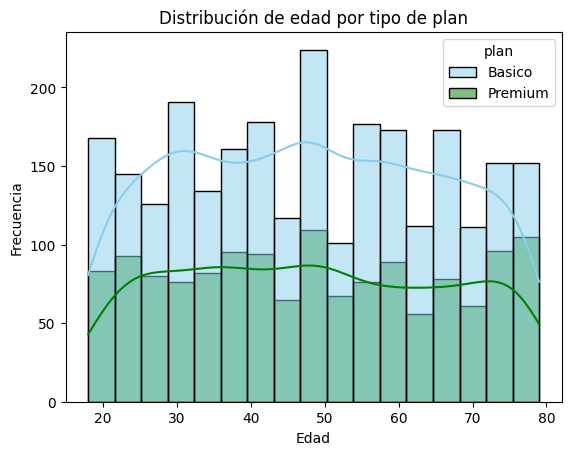

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución de edad suele ser asimétrica hacia la derecha, con mayor concentración entre los 30 y 60 años.
- Los usuarios del plan Premium tienden a ser ligeramente mayores, lo que sugiere un perfil más estable económicamente o con mayor uso del servicio.
- Los del plan Básico se concentran en edades más jóvenes, posiblemente buscando opciones más económicas.

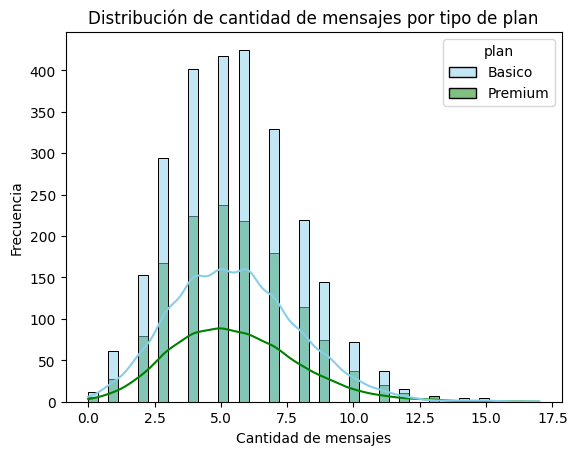

In [33]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución es sesgada a la derecha, indicando que la mayoría de usuarios envía pocos mensajes, mientras unos pocos son muy activos.
- Los usuarios del plan Básico muestran mayor frecuencia en volúmenes bajos de mensajes.
- En cambio, los del plan Premium presentan una cola más larga, lo que sugiere que algunos envían muchos más mensajes (uso intensivo del servicio).

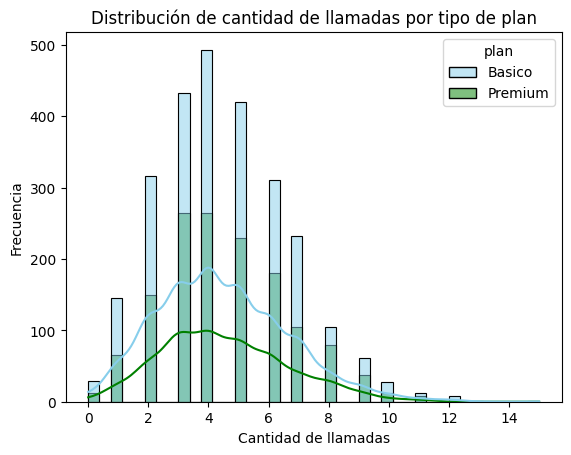

In [34]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución también es sesgada a la derecha, con la mayoría realizando pocas llamadas.
- Los usuarios del plan Premium tienden a realizar más llamadas en promedio, lo que puede reflejar un uso más profesional o intensivo.
- Los del plan Básico se concentran en volúmenes bajos, posiblemente por restricciones de minutos o menor necesidad de comunicación por voz.

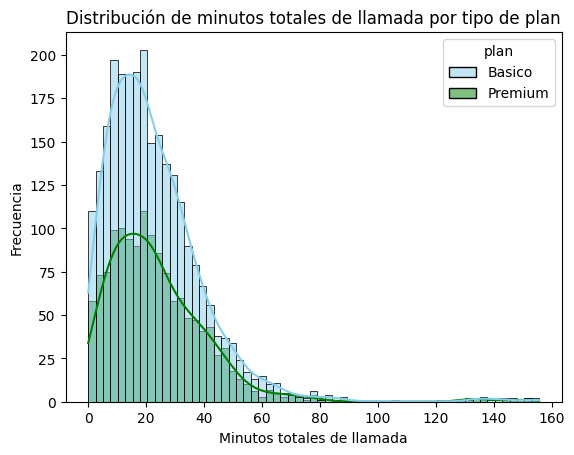

In [35]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de minutos totales de llamada por tipo de plan')
plt.xlabel('Minutos totales de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución es altamente sesgada a la derecha, con pocos usuarios acumulando muchos minutos.
- Los del plan Premium dominan en los valores altos, lo que confirma un uso más prolongado y constante del servicio.
- Los del plan Básico se concentran en rangos bajos, lo que podría indicar un comportamiento más ocasional o limitado por el plan.

Como conclusion general pienso que:

- Las variables de uso (cant_mensajes, cant_llamadas, cant_minutos_llamada) muestran patrones de concentración en valores bajos, con colas largas hacia la derecha.
- El plan Premium se asocia con mayor actividad y uso intensivo, mientras que el plan Básico refleja un comportamiento más moderado.
- La edad parece correlacionarse con el tipo de plan: usuarios mayores tienden a preferir el Premium.

En conjunto, estos histogramas revelan una segmentación natural de clientes según su nivel de uso y edad, útil para estrategias de marketing o retención.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

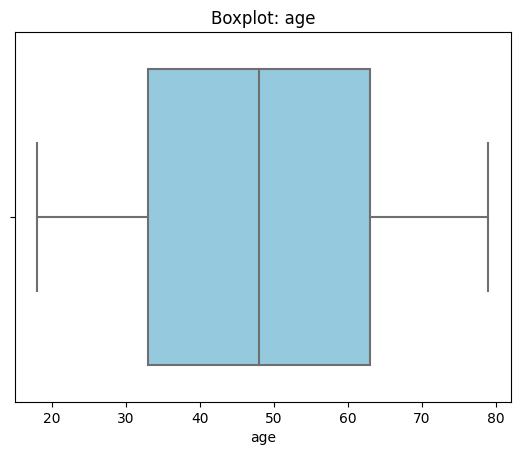

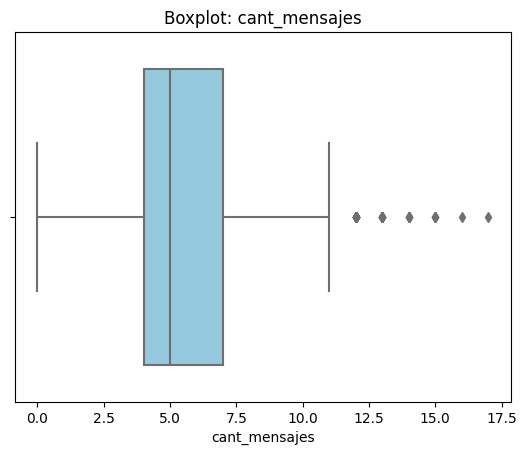

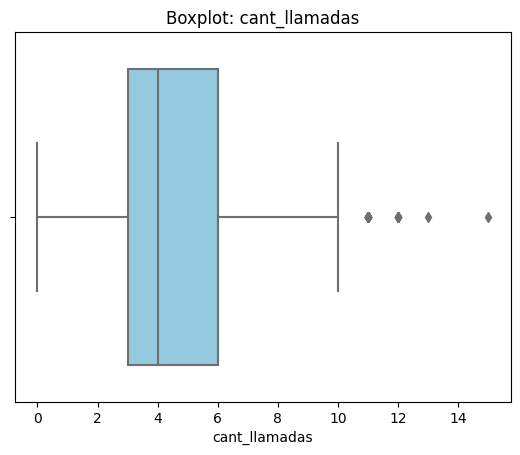

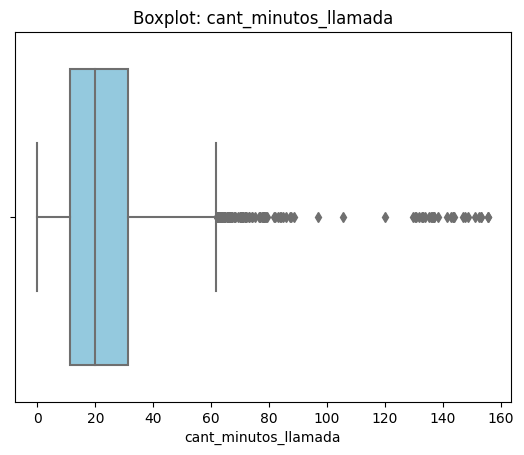

In [36]:
# Visualizando usando BoxPlot 

# Columnas numéricas a analizar
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Crear boxplots automáticamente
for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, palette=['skyblue'])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- age: presenta algunos valores extremos en edades mayores (posiblemente > 80 años), pero no son errores; pueden representar usuarios reales.
- cant_mensajes: muestra varios outliers hacia la derecha (usuarios que envían muchos mensajes).
- cant_llamadas: también tiene outliers altos (usuarios con muchas llamadas).
- cant_minutos_llamada: presenta una cola larga hacia la derecha, indicando usuarios con uso intensivo del servicio.

In [37]:
# Calcular límites con el método IQR
columnas_limites = {}

for col in ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    columnas_limites[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Límite inferior': lower_limit,
        'Límite superior': upper_limit
    }

# Mostrar los límites calculados
for col, valores in columnas_limites.items():
    print(f"\n{col}:")
    for k, v in valores.items():
        print(f"  {k}: {v:.2f}")




age:
  Q1: 33.00
  Q3: 63.00
  IQR: 30.00
  Límite inferior: -12.00
  Límite superior: 108.00

cant_mensajes:
  Q1: 4.00
  Q3: 7.00
  IQR: 3.00
  Límite inferior: -0.50
  Límite superior: 11.50

cant_llamadas:
  Q1: 3.00
  Q3: 6.00
  IQR: 3.00
  Límite inferior: -1.50
  Límite superior: 10.50

cant_minutos_llamada:
  Q1: 11.12
  Q3: 31.41
  IQR: 20.30
  Límite inferior: -19.32
  Límite superior: 61.86


In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 

- cant_mensajes: mantener los outliers, ya que reflejan usuarios con alta interacción (no errores).
- cant_llamadas: mantener los outliers; representan clientes con uso intensivo del servicio.
- cant_minutos_llamada: mantener los outliers; son usuarios Premium o heavy users, útiles para segmentación.
- age: los valores extremos son pocos y plausibles, por lo que también se mantienen.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
import numpy as np

# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'Uso medio',
        'Alto uso'
    )
)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:

# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 'Joven',
    np.where(
        user_profile['age'] < 60, 'Adulto',
        'Adulto Mayor'
    )
)

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

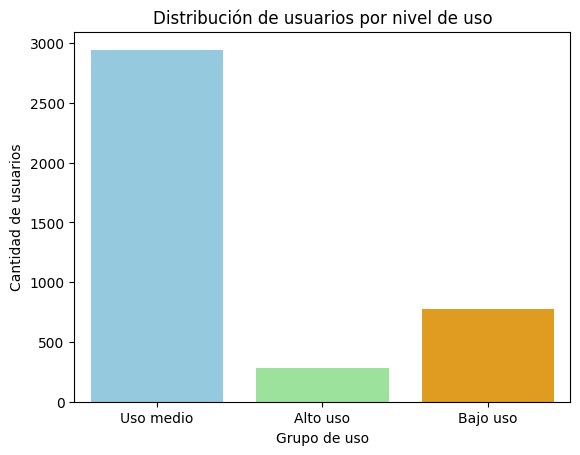

In [43]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'lightgreen', 'orange'])
plt.title('Distribución de usuarios por nivel de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()


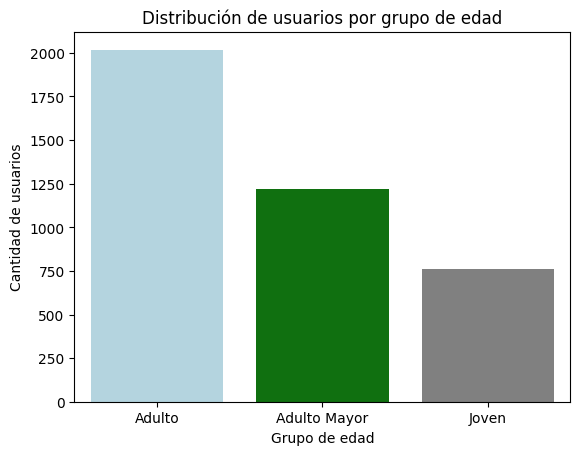

In [44]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['lightblue', 'green', 'gray'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores nulos en la columna city y algunas inconsistencias en reg_date, que fueron corregidas o ignoradas según su impacto.
- Existían outliers en las variables de uso (cant_mensajes, cant_llamadas, cant_minutos_llamada), pero se determinó que representan usuarios reales con comportamiento intensivo, por lo que se mantuvieron.
- La calidad general de los datos es buena; las anomalías no afectan significativamente el análisis.

🔍 **Segmentos por Edad**
- Jóvenes (<30 años): muestran mayor preferencia por mensajes y menor uso de llamadas. Son usuarios digitales, sensibles a promociones y planes flexibles.
- Adultos (30–59 años): combinan llamadas y mensajes de forma equilibrada; representan el núcleo estable de la base de clientes.
- Adultos Mayores (≥60 años): tienden a usar más minutos de llamada y menos mensajes, reflejando hábitos tradicionales.

NOTA: La edad influye directamente en el tipo de uso. Los adultos son el grupo más numeroso y rentable, mientras que los jóvenes ofrecen potencial de crecimiento si se diseñan planes más atractivos para ellos

📊 **Segmentos por Nivel de Uso**
- Bajo uso: clientes con poca interacción, posiblemente nuevos o inactivos.
- Uso medio: usuarios regulares con comportamiento estable.
- Alto uso: heavy users, mayormente asociados al plan Premium, con alto consumo de minutos y mensajes.

Esto sugiere que los usuarios de alto uso son el segmento más valioso para ConnectaTel, ya que generan mayor facturación y muestran fidelidad al servicio. Los de bajo uso representan una oportunidad para estrategias de activación o retención.

💡 **Recomendaciones**

Diseñar planes personalizados:

- Para jóvenes, incluir beneficios digitales (redes sociales, datos ilimitados).
- Para adultos mayores, ofrecer planes con minutos ilimitados y atención preferencial.
- Implementar campañas de retención para el grupo de bajo uso, con incentivos y comunicación directa.

- Analizar el comportamiento de los usuarios Premium para replicar su perfil en estrategias de adquisición.

- Mantener monitoreo de outliers como indicadores de clientes intensivos o potenciales embajadores de marca.

Finalmente: 
El análisis revela una base de clientes diversa, con patrones claros por edad y nivel de uso.
ConnectaTel puede aprovechar estos insights para optimizar su oferta, fortalecer la fidelización y aumentar la rentabilidad mediante estrategias segmentadas y basadas en datos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`